In [ ]:
# images_long_df.to_csv('data/profiles_long.csv', index=False)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/profiles_features.csv')

In [2]:
df = df[df['modality'] == 'nissl']

In [3]:
df['id_region'] = df['brain_id'] + '_' + df['region']

In [4]:
import ast

df["Features"] = df["Features"].apply(lambda s: [float(x) for x in s.strip("[]").split()])

In [5]:
from scipy.spatial.distance import mahalanobis
import numpy as np

# stack the arrays into a matrix
feat_matrix = np.stack(df["Features"].values) # shape (n, 10)

# compute covariance and invert
cov = np.cov(feat_matrix, rowvar=False)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = np.linalg.inv(cov)

# pairwise distances
from scipy.spatial.distance import pdist, squareform

D = squareform(pdist(feat_matrix, metric="mahalanobis", VI=cov_inv))

<Axes: >

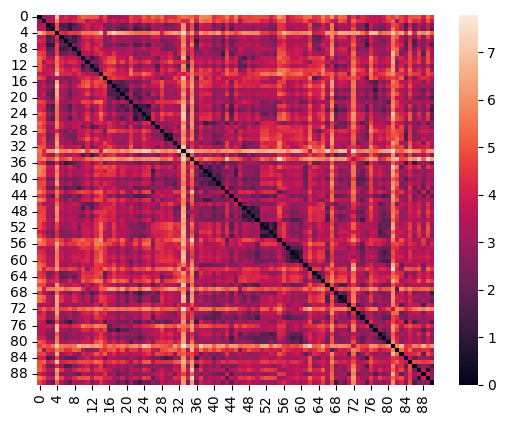

In [6]:
sns.heatmap(D)

In [7]:
from skbio.stats.distance import DistanceMatrix

dm = DistanceMatrix(D, ids=df.index)

In [8]:
from skbio.stats.distance import permanova

result = permanova(dm, grouping=df["id_region"], permutations=9999)
print(result)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      91
number of groups                 17
test statistic             3.985055
p-value                      0.0001
number of permutations         9999
Name: PERMANOVA results, dtype: object


c:\Users\P70089795\AppData\Local\miniforge3\envs\napari-env\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\P70089795\AppData\Local\miniforge3\envs\napari-env\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\P70089795\AppData\Local\miniforge3\envs\napari-env\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Text(0, 0.5, 'MDS 2')

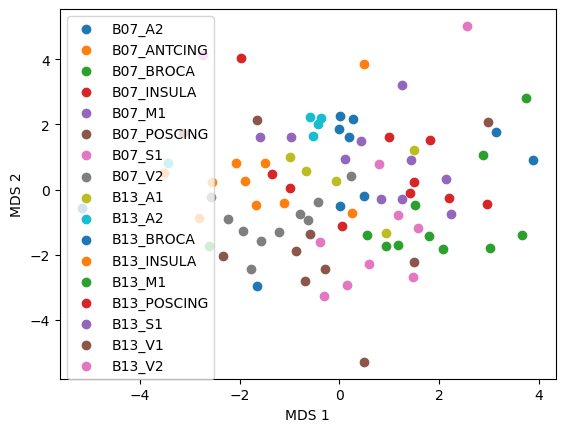

In [9]:
from sklearn.manifold import MDS

embedding = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = embedding.fit_transform(D)

import matplotlib.pyplot as plt
for region in df["id_region"].unique():
    mask = df["id_region"] == region
    plt.scatter(coords[mask, 0], coords[mask, 1], label=region)
plt.legend()
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")

In [ ]:
# multivariate ttests between all combinations fail, too many variables (10) for too little points

import pingouin as pg
import numpy as np
from itertools import combinations

# expand the feature arrays into a DataFrame with columns
feat_matrix = np.stack(df["Features"].values)
feat_df = pd.DataFrame(feat_matrix, columns=[f"f{i}" for i in range(10)])
feat_df["id_region"] = df["id_region"].values

# pairwise Hotelling T² tests
feature_cols = [f"f{i}" for i in range(10)]
regions = feat_df["id_region"].unique()

results = []
for r1, r2 in combinations(regions, 2):
    X = feat_df.loc[feat_df["id_region"] == r1, feature_cols]
    Y = feat_df.loc[feat_df["id_region"] == r2, feature_cols]
    res = pg.multivariate_ttest(X, Y)
    results.append({"r1": r1, "r2": r2, **res.iloc[0].to_dict()})

results_df = pd.DataFrame(results)

# Bonferroni correction
results_df["pval_corrected"] = np.minimum(results_df["pval"] * len(results_df), 1.0)



In [ ]:
# we reduce the amount of features using PCA
import pingouin as pg
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.decomposition import PCA

# PCA on features
feat_matrix = np.stack(df["Features"].values)
pca = PCA(n_components=3)
scores = pca.fit_transform(feat_matrix)

feat_df = pd.DataFrame(scores, columns=["PC1", "PC2", "PC3"])
feat_df["id_region"] = df["id_region"].values

# pairwise Hotelling T²
feature_cols = ["PC1", "PC2", "PC3"]
regions = feat_df["id_region"].unique()

results = []
for r1, r2 in combinations(regions, 2):
    X = feat_df.loc[feat_df["id_region"] == r1, feature_cols]
    Y = feat_df.loc[feat_df["id_region"] == r2, feature_cols]
    res = pg.multivariate_ttest(X, Y)
    results.append({"r1": r1, "r2": r2, **res.iloc[0].to_dict()})

results_df = pd.DataFrame(results)
results_df["pval_corrected"] = np.minimum(results_df["pval"] * len(results_df), 1.0)

In [16]:
feat_df

,PC1,PC2,PC3,id_region
0,37.977248,-4.249826,4.070400,B07_A2
1,40.524047,-5.114441,4.627976,B07_A2
2,-7.378516,7.225208,3.370856,B07_A2
3,-4.975072,2.487273,4.218136,B07_A2
4,-81.587437,20.646287,5.340262,B07_A2
...,...,...,...,...
86,-19.686513,12.053283,1.917987,B13_V2
87,5.234501,8.180896,-2.076489,B13_V2
88,42.009064,-2.827757,1.672120,B13_V2
89,0.311935,10.748349,-3.765950,B13_V2


In [20]:
results_df[results_df['pval_corrected'] < 0.05]

,r1,r2,T2,F,df1,df2,pval,pval_corrected
8,B07_A2,B13_A2,530.793409,132.698352,3.0,6.0,0.000007,0.000968
9,B07_A2,B13_BROCA,590.388112,147.597028,3.0,6.0,0.000005,0.000707
22,B07_ANTCING,B13_A1,169.800960,42.450240,3.0,6.0,0.000196,0.026638
23,B07_ANTCING,B13_A2,261.040879,65.260220,3.0,6.0,0.000057,0.007734
24,B07_ANTCING,B13_BROCA,380.217610,95.054403,3.0,6.0,0.000019,0.002583
50,B07_INSULA,B13_A2,156.280040,39.070010,3.0,6.0,0.000248,0.033722
51,B07_INSULA,B13_BROCA,180.743805,45.185951,3.0,6.0,0.000164,0.022291
61,B07_M1,B13_A1,150.805013,37.701253,3.0,6.0,0.000274,0.037307
73,B07_POSCING,B13_A2,251.058456,62.764614,3.0,6.0,0.000064,0.008659
91,B07_V2,B13_A1,53.280124,15.027727,3.0,11.0,0.000331,0.045054


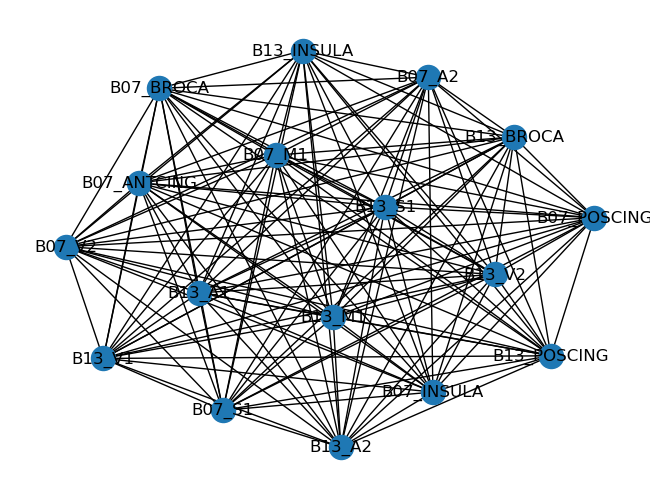

In [21]:
import networkx as nx
G= nx.from_pandas_edgelist(results_df, "r1", "r2")

nx.draw(G, with_labels=True)
plt.show()

In [22]:
# mean Mahalanobis distance per region to all others
region_labels = df["id_region"].values
unique_regions = np.unique(region_labels)

mean_distances = {}
for region in unique_regions:
    mask_self = region_labels == region
    mask_other = ~mask_self
    # mean distance from this region's profiles to all other profiles
    mean_distances[region] = D[np.ix_(mask_self, mask_other)].mean()

ranking = pd.Series(mean_distances).sort_values(ascending=False)
print(ranking)

B07_S1         4.453518
B13_V1         4.237532
B07_A2         4.141726
B13_INSULA     3.999027
B07_BROCA      3.987542
B13_M1         3.731553
B13_A2         3.711549
B13_BROCA      3.680043
B07_POSCING    3.667839
B13_POSCING    3.595760
B07_INSULA     3.586875
B13_V2         3.539481
B13_S1         3.512210
B07_M1         3.504687
B07_V2         3.462680
B13_A1         3.383356
B07_ANTCING    3.373420
dtype: float64
